In [1]:
import numpy as np
import pandas as pd
import catboost
from catboost import CatBoostClassifier 
import sklearn
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc  
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, recall_score, 
    precision_score, f1_score
)


In [2]:
dictionary=pd.read_csv(r'./TelcoChurn/data_dictionary.csv')
dictionary

,Acronyms,Description
0,CIRCLE_ID,Telecom circle area to which the customer belo...
1,LOC,Local calls within same telecom circle
2,STD,STD calls outside the calling circle
3,IC,Incoming calls
4,OG,Outgoing calls
5,T2T,Operator T to T ie within same operator mobile...
6,T2M,Operator T to other operator mobile
7,T2O,Operator T to other operator fixed line
8,T2F,Operator T to fixed lines of T
9,T2C,Operator T to its own call center


In [3]:
train = pd.read_csv(r"./TelcoChurn/train.csv")
test = pd.read_csv(r"./TelcoChurn/test.csv")

train.head()

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,last_date_of_month_6,last_date_of_month_7,last_date_of_month_8,arpu_6,arpu_7,...,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
0,0,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,31.277,87.009,...,0,0,NaN,NaN,NaN,1958,0.0,0.0,0.0,0
1,1,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,0.000,122.787,...,0,0,NaN,1.0,NaN,710,0.0,0.0,0.0,0
2,2,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,60.806,103.176,...,0,0,NaN,NaN,NaN,882,0.0,0.0,0.0,0
3,3,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,156.362,205.260,...,0,0,NaN,NaN,NaN,982,0.0,0.0,0.0,0
4,4,109,0.0,0.0,0.0,6/30/2014,7/31/2014,8/31/2014,240.708,128.191,...,1,0,1.0,1.0,1.0,647,0.0,0.0,0.0,0


In [4]:
train.info(verbose = True, show_counts = True)
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 69999 entries, 0 to 69998
Data columns (total 172 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    id                        69999 non-null  int64  
 1    circle_id                 69999 non-null  int64  
 2    loc_og_t2o_mou            69297 non-null  float64
 3    std_og_t2o_mou            69297 non-null  float64
 4    loc_ic_t2o_mou            69297 non-null  float64
 5    last_date_of_month_6      69999 non-null  str    
 6    last_date_of_month_7      69600 non-null  str    
 7    last_date_of_month_8      69266 non-null  str    
 8    arpu_6                    69999 non-null  float64
 9    arpu_7                    69999 non-null  float64
 10   arpu_8                    69999 non-null  float64
 11   onnet_mou_6               67231 non-null  float64
 12   onnet_mou_7               67312 non-null  float64
 13   onnet_mou_8               66296 non-null  float64
 14  

,id,circle_id,loc_og_t2o_mou,std_og_t2o_mou,loc_ic_t2o_mou,arpu_6,arpu_7,arpu_8,onnet_mou_6,onnet_mou_7,...,sachet_3g_7,sachet_3g_8,fb_user_6,fb_user_7,fb_user_8,aon,aug_vbc_3g,jul_vbc_3g,jun_vbc_3g,churn_probability
count,69999.000000,69999.0,69297.0,69297.0,69297.0,69999.000000,69999.000000,69999.000000,67231.000000,67312.000000,...,69999.000000,69999.000000,17568.000000,17865.000000,18417.000000,69999.000000,69999.000000,69999.000000,69999.00000,69999.000000
mean,34999.000000,109.0,0.0,0.0,0.0,283.134365,278.185912,278.858826,133.153275,133.894438,...,0.081444,0.085487,0.916325,0.909544,0.890319,1220.639709,68.108597,65.935830,60.07674,0.101887
std,20207.115084,0.0,0.0,0.0,0.0,334.213918,344.366927,351.924315,299.963093,311.277193,...,0.634547,0.680035,0.276907,0.286842,0.312501,952.426321,269.328659,267.899034,257.22681,0.302502
min,0.000000,109.0,0.0,0.0,0.0,-2258.709000,-1289.715000,-945.808000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,180.000000,0.000000,0.000000,0.00000,0.000000
25%,17499.500000,109.0,0.0,0.0,0.0,93.581000,86.714000,84.095000,7.410000,6.675000,...,0.000000,0.000000,1.000000,1.000000,1.000000,468.000000,0.000000,0.000000,0.00000,0.000000
50%,34999.000000,109.0,0.0,0.0,0.0,197.484000,191.588000,192.234000,34.110000,32.280000,...,0.000000,0.000000,1.000000,1.000000,1.000000,868.000000,0.000000,0.000000,0.00000,0.000000
75%,52498.500000,109.0,0.0,0.0,0.0,370.791000,365.369500,369.909000,119.390000,115.837500,...,0.000000,0.000000,1.000000,1.000000,1.000000,1813.000000,0.000000,0.000000,0.00000,0.000000
max,69998.000000,109.0,0.0,0.0,0.0,27731.088000,35145.834000,33543.624000,7376.710000,8157.780000,...,33.000000,41.000000,1.000000,1.000000,1.000000,4337.000000,12916.220000,9165.600000,11166.21000,1.000000


Null Data


--- Checking for Missing Values ---
Features with the highest percentage of missing values:
max_rech_data_6             74.902499
fb_user_6                   74.902499
date_of_last_rech_data_6    74.902499
av_rech_amt_data_6          74.902499
night_pck_user_6            74.902499
count_rech_2g_6             74.902499
total_rech_data_6           74.902499
arpu_2g_6                   74.902499
count_rech_3g_6             74.902499
arpu_3g_6                   74.902499
arpu_3g_7                   74.478207
count_rech_2g_7             74.478207
av_rech_amt_data_7          74.478207
max_rech_data_7             74.478207
total_rech_data_7           74.478207
arpu_2g_7                   74.478207
date_of_last_rech_data_7    74.478207
night_pck_user_7            74.478207
fb_user_7                   74.478207
count_rech_3g_7             74.478207
total_rech_data_8           73.689624
max_rech_data_8             73.689624
date_of_last_rech_data_8    73.689624
count_rech_2g_8             73.68

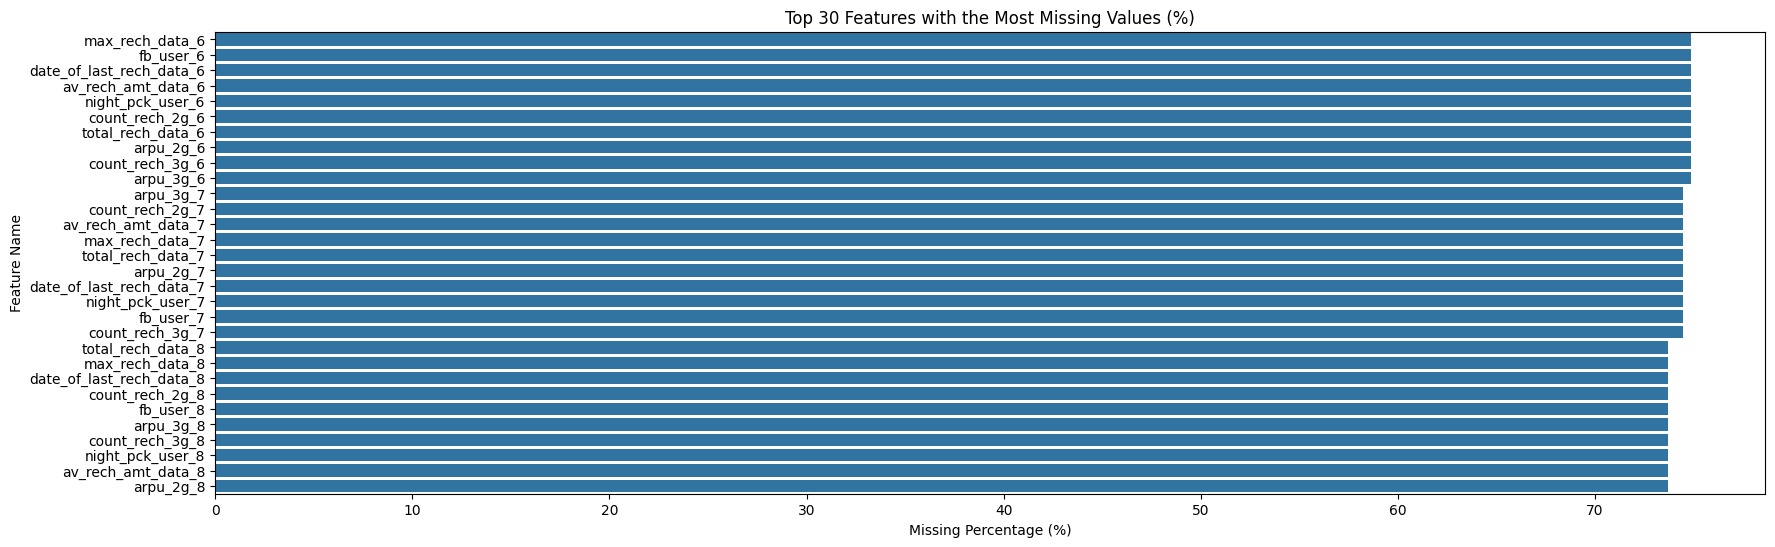

In [5]:
print("\n--- Checking for Missing Values ---")
missing_percentages = (train.isnull().sum() / len(train)) * 100
missing_features = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

print("Features with the highest percentage of missing values:")
print(missing_features.head(30))

# Visualizing Missing Values
plt.figure(figsize=(20, 6))
sns.barplot(x=missing_features.head(30).values, y=missing_features.head(30).index)
plt.title('Top 30 Features with the Most Missing Values (%)')
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Feature Name')
plt.show()

Data Imbalance

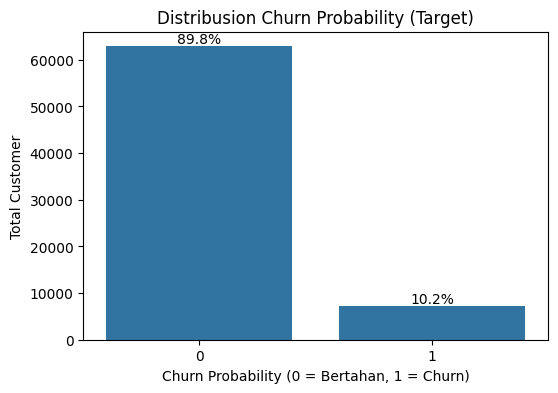

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x='churn_probability')
plt.title('Distribusion Churn Probability (Target)')
plt.xlabel('Churn Probability (0 = Bertahan, 1 = Churn)')
plt.ylabel('Total Customer')

total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

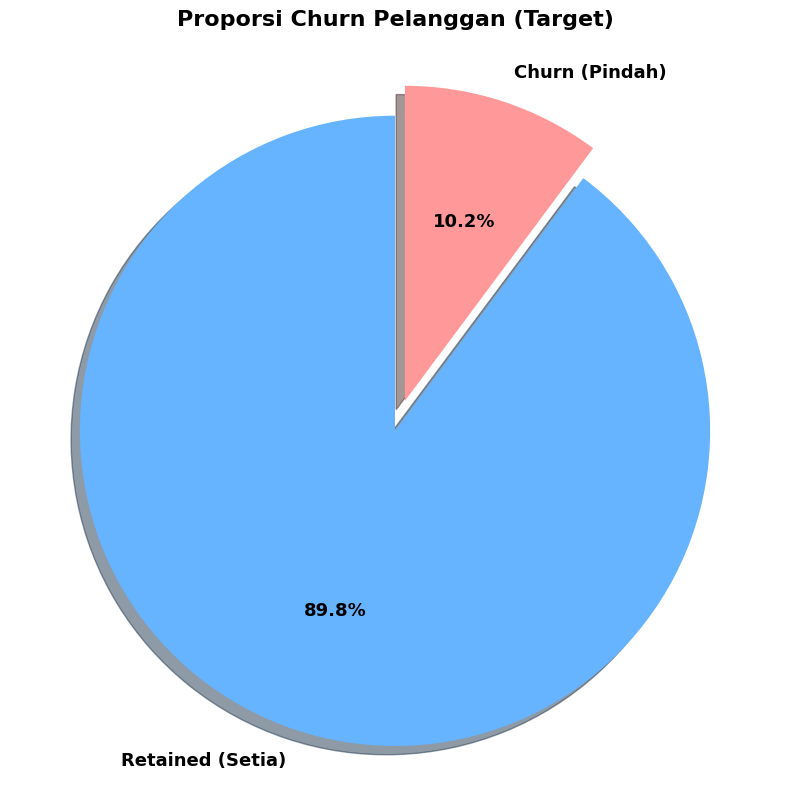

In [7]:
churn_counts = train['churn_probability'].value_counts()
labels = ['Retained (Setia)', 'Churn (Pindah)']
colors = ['#66b3ff', '#ff9999'] 
explode = (0, 0.1)  

plt.figure(figsize=(8, 8))
plt.pie(
    churn_counts, 
    labels=labels, 
    autopct='%1.1f%%',   
    startangle=90,       
    colors=colors, 
    explode=explode,     
    shadow=True,         
    textprops={'fontsize': 13, 'fontweight': 'bold'}
)

plt.title('Proporsi Churn Pelanggan (Target)', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')  

plt.tight_layout()
plt.show()

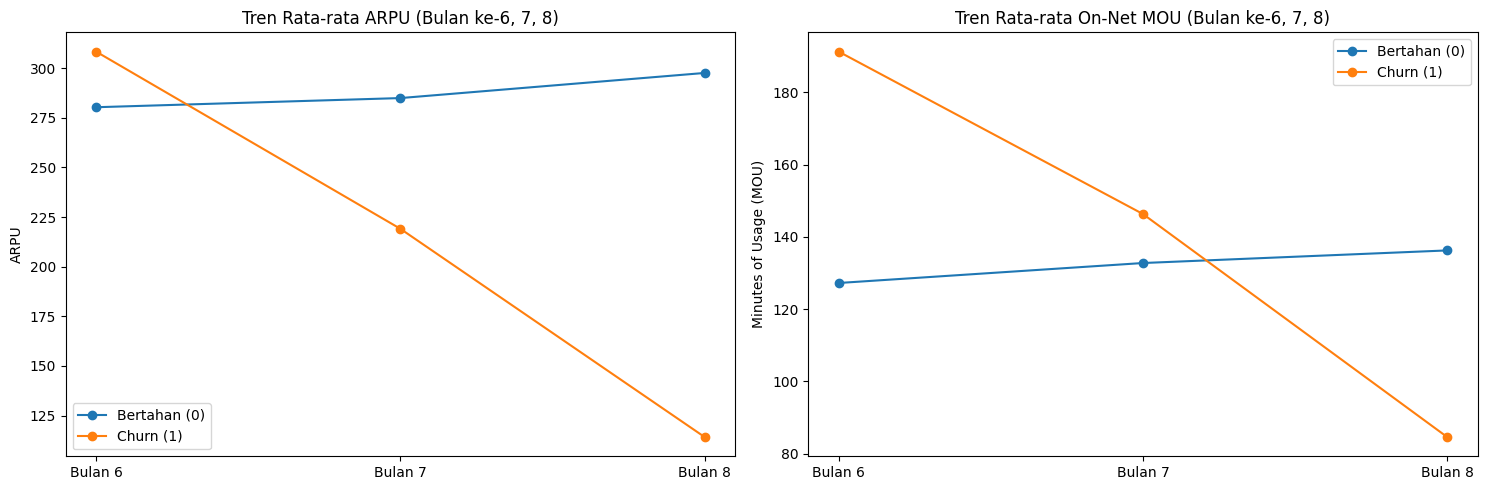

In [8]:
arpu_cols = ['arpu_6', 'arpu_7', 'arpu_8']
mou_cols = ['onnet_mou_6', 'onnet_mou_7', 'onnet_mou_8']

churn_arpu_trend = train.groupby('churn_probability')[arpu_cols].mean().T
churn_mou_trend = train.groupby('churn_probability')[mou_cols].mean().T

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

churn_arpu_trend.plot(kind='line', marker='o', ax=axes[0])
axes[0].set_title('Tren Rata-rata ARPU (Bulan ke-6, 7, 8)')
axes[0].set_xticks([0, 1, 2])
axes[0].set_xticklabels(['Bulan 6', 'Bulan 7', 'Bulan 8'])
axes[0].set_ylabel('ARPU')
axes[0].legend(['Bertahan (0)', 'Churn (1)'])

churn_mou_trend.plot(kind='line', marker='o', ax=axes[1])
axes[1].set_title('Tren Rata-rata On-Net MOU (Bulan ke-6, 7, 8)')
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Bulan 6', 'Bulan 7', 'Bulan 8'])
axes[1].set_ylabel('Minutes of Usage (MOU)')
axes[1].legend(['Bertahan (0)', 'Churn (1)'])

plt.tight_layout()
plt.show()

Korelasi


--- Calculating Correlation Matrix ---
Top 15 Features with Highest Correlation to Churn:
churn_probability     1.000000
aon                   0.135177
total_ic_mou_7        0.120197
std_og_mou_6          0.107870
loc_ic_t2m_mou_7      0.099544
loc_ic_mou_7          0.098318
loc_og_t2m_mou_7      0.088988
loc_og_mou_7          0.087851
roam_og_mou_7         0.086646
std_og_t2t_mou_6      0.084323
std_og_t2m_mou_6      0.081825
max_rech_amt_7        0.073366
total_ic_mou_6        0.070951
loc_ic_mou_6          0.069804
last_day_rch_amt_7    0.069795
loc_ic_t2m_mou_6      0.068057
roam_ic_mou_7         0.068012
total_rech_amt_7      0.063978
total_rech_num_7      0.062956
loc_og_t2m_mou_6      0.062760
loc_og_mou_6          0.062331
Name: churn_probability, dtype: float64


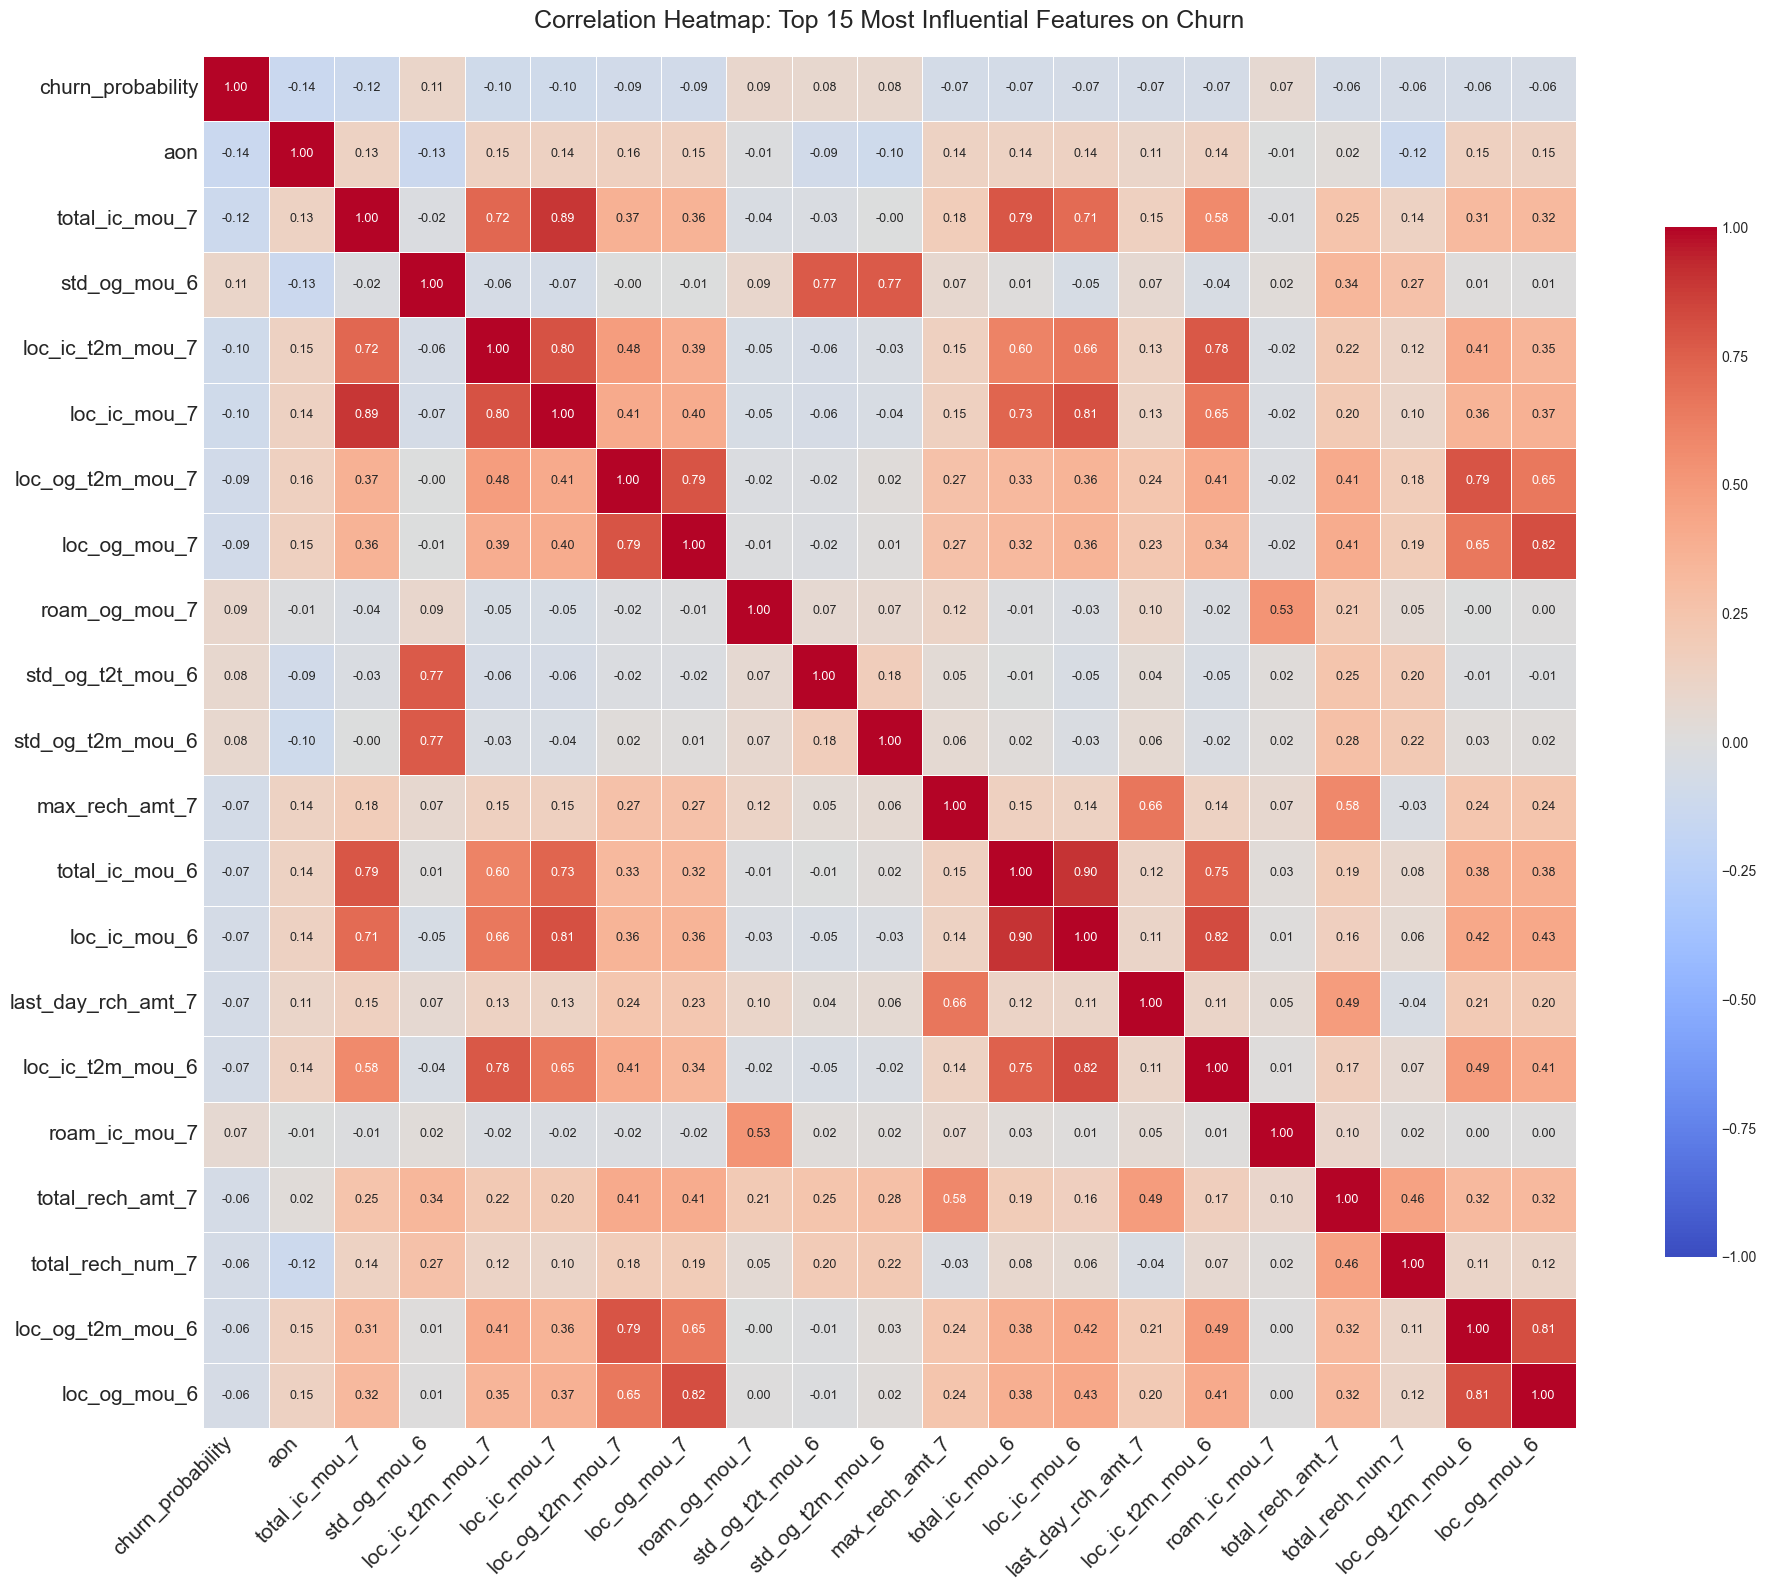

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
print("\n--- Calculating Correlation Matrix ---")
cols_to_exclude = [c for c in train.columns if str(c).endswith('_8') or 'aug' in str(c).lower()]
train_eda = train.drop(columns=cols_to_exclude, errors='ignore')

numeric_train = train_eda.select_dtypes(include=['number'])

correlation_with_target = numeric_train.corr()['churn_probability'].abs().sort_values(ascending=False)
top_15_features = correlation_with_target.index[:21]

print("Top 15 Features with Highest Correlation to Churn:")
print(correlation_with_target.head(21))

top_15_train = train[top_15_features]
top_15_corr = top_15_train.corr()

plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(top_15_corr, dtype=bool))

# Plot heatmap
sns.heatmap(
    top_15_corr, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75},
    annot_kws={"size": 9} 
)

plt.title('Correlation Heatmap: Top 15 Most Influential Features on Churn', fontsize=18, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()

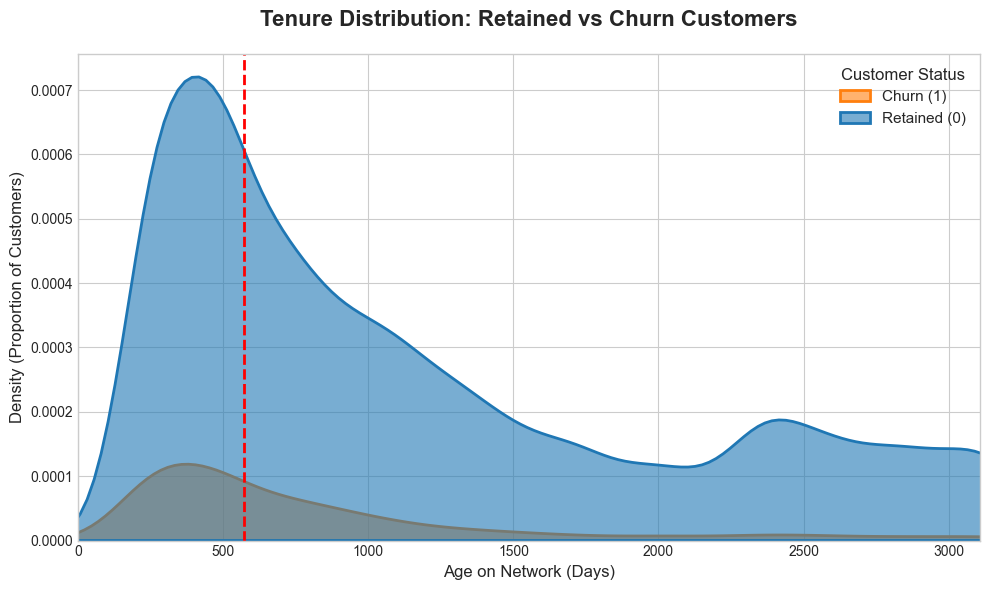

In [10]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.kdeplot(data=train, x='aon', hue='churn_probability', fill=True, 
            palette=['#1f77b4', '#ff7f0e'], 
            alpha=0.6, linewidth=2)

plt.title('Tenure Distribution: Retained vs Churn Customers', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age on Network (Days)', fontsize=12)
plt.ylabel('Density (Proportion of Customers)', fontsize=12)

plt.legend(title='Customer Status', labels=['Churn (1)', 'Retained (0)'], fontsize=11, title_fontsize=12)

plt.axvline(x=train[train['churn_probability']==1]['aon'].median(), color='red', linestyle='--', linewidth=2, label='Median Churn')

plt.xlim(0, train['aon'].quantile(0.95))
plt.tight_layout()
plt.show()


--- Creating Bar Plot Visualization for Tenure Category (AON) ---


C:\Users\USER\AppData\Local\Temp\ipykernel_18036\2201231091.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['tenure_group'] = pd.cut(train['aon'], bins=bins, labels=labels, right=False)


<Figure size 1200x600 with 0 Axes>

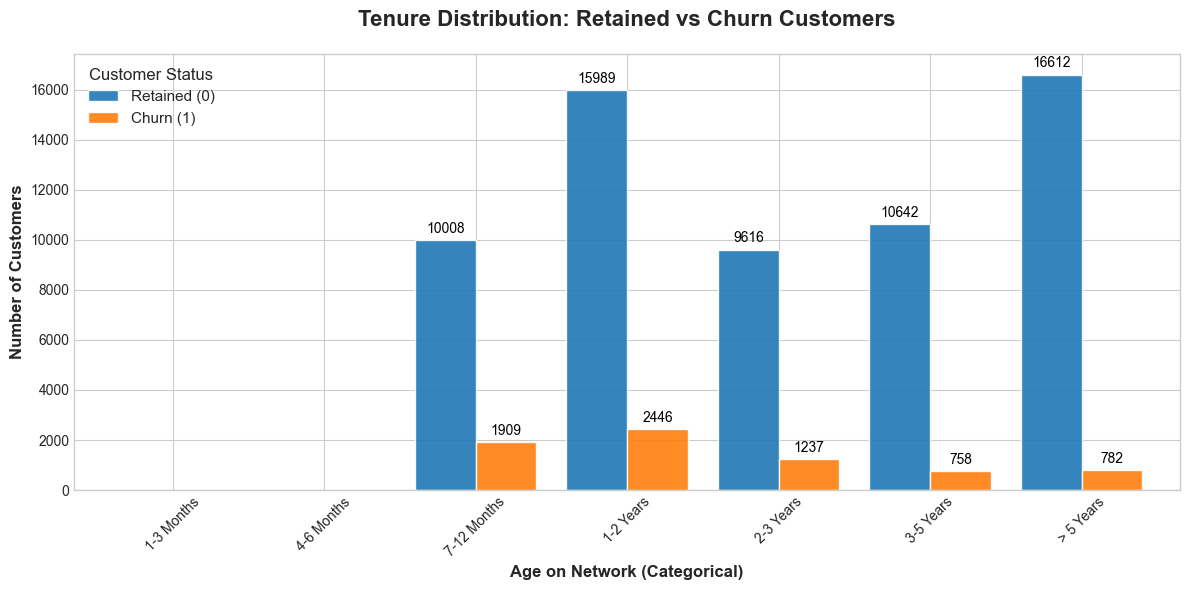

In [11]:
print("\n--- Creating Bar Plot Visualization for Tenure Category (AON) ---")

bins = [0, 90, 180, 365, 730, 1095, 1825, np.inf]
labels = [
    '1-3 Months', '4-6 Months', '7-12 Months', 
    '1-2 Years', '2-3 Years', '3-5 Years', '> 5 Years'
]

train['tenure_group'] = pd.cut(train['aon'], bins=bins, labels=labels, right=False)

grouped_data = train.groupby(['tenure_group', 'churn_probability'], observed=False).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))

ax = grouped_data.plot(
    kind='bar', 
    figsize=(12, 6), 
    width=0.8, 
    color=['#1f77b4', '#ff7f0e'],
    alpha=0.9
)

# Customizing text and labels
plt.title('Tenure Distribution: Retained vs Churn Customers', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age on Network (Categorical)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Customers', fontsize=12, fontweight='bold')

plt.legend(title='Customer Status', labels=['Retained (0)', 'Churn (1)'], fontsize=11, title_fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', xytext=(0, 3), 
                    textcoords='offset points')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
def preprocess_telecom_data_early_warning(train, is_train=True):
    """
    Function to process telecom churn data using ONLY month 6 & 7 
    (Early Warning System).
    """
    data = train.copy()
    cols_to_drop = ['id', 'circle_id']
    
    # --- 1. Data Leakage Handling ---
    # Drop all columns related to month 8
    cols_month_8 = [c for c in data.columns if c.endswith('_8') or 'aug' in c.lower()]
    cols_to_drop.extend(cols_month_8)
    
    # Drop date columns
    date_cols = [c for c in data.columns if 'date' in c]
    cols_to_drop.extend(date_cols)
    
    # Drop columns that have only 1 unique value (zero variance)
    single_value_cols = [c for c in data.columns if data[c].nunique() <= 1]
    cols_to_drop.extend(single_value_cols)
    
    cols_to_drop = list(set(cols_to_drop).intersection(data.columns))
    data = data.drop(columns=cols_to_drop)
    
    # --- 2. Missing Value Handling ---
    # 1. Data and Internet Package Columns (Fill NaN with 0)
    data_recharge_cols = [
        'total_rech_data_6', 'total_rech_data_7',
        'max_rech_data_6', 'max_rech_data_7',
        'count_rech_2g_6', 'count_rech_2g_7',
        'count_rech_3g_6', 'count_rech_3g_7',
        'av_rech_amt_data_6', 'av_rech_amt_data_7',
        'arpu_3g_6', 'arpu_3g_7',
        'arpu_2g_6', 'arpu_2g_7'
    ]
    for col in data_recharge_cols:
        if col in data.columns:
            data[col] = data[col].fillna(0)
            
    # 2. Flag / Categorical Columns (Fill NaN with -1)
    cat_cols = [
        'night_pck_user_6', 'night_pck_user_7',
        'fb_user_6', 'fb_user_7'
    ]
    for col in cat_cols:
        if col in data.columns:
            data[col] = data[col].fillna(-1).astype(int)
            
    # 3. Other Numeric Features 
    numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
    if 'churn_probability' in numeric_cols:
        numeric_cols = numeric_cols.drop('churn_probability')
        
    data[numeric_cols] = data[numeric_cols].fillna(0)
    
    # --- 3. Feature Engineering (Month 7 vs Month 6 Trends) ---
    # 1. ARPU (Billing) Trend
    if 'arpu_6' in data.columns and 'arpu_7' in data.columns:
        data['diff_arpu_7_vs_6'] = data['arpu_7'] - data['arpu_6']
        
    # 2. Total Voice Usage (MOU) and its Trend
    for m in ['6', '7']:
        if f'onnet_mou_{m}' in data.columns and f'offnet_mou_{m}' in data.columns:
            data[f'total_mou_{m}'] = data[f'onnet_mou_{m}'] + data[f'offnet_mou_{m}']
            
    if 'total_mou_6' in data.columns and 'total_mou_7' in data.columns:
        data['diff_mou_7_vs_6'] = data['total_mou_7'] - data['total_mou_6']
        
    # 3. Recharge Amount Trend
    if 'total_rech_amt_6' in data.columns and 'total_rech_amt_7' in data.columns:
        data['diff_rech_amt_7_vs_6'] = data['total_rech_amt_7'] - data['total_rech_amt_6']

    # 4. Data Recharge Trend
    if 'total_rech_data_6' in data.columns and 'total_rech_data_7' in data.columns:
        data['diff_rech_data_7_vs_6'] = data['total_rech_data_7'] - data['total_rech_data_6']

    return data


# --- Apply Function to Datasets ---
train_clean = preprocess_telecom_data_early_warning(train, is_train=True)
test_clean = preprocess_telecom_data_early_warning(test, is_train=False)

X = train_clean.drop(columns=['churn_probability'])
y = train_clean['churn_probability']
X_test = test_clean 

# Define categorical features for CatBoost
categorical_features_names = [
    'night_pck_user_6', 'night_pck_user_7',
    'fb_user_6', 'fb_user_7'
]
cat_features = [col for col in categorical_features_names if col in X.columns]

print(f"\nDone! Feature X is ready to use. Current number of X columns: {X.shape[1]}")

C:\Users\USER\AppData\Local\Temp\ipykernel_18036\739829226.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['diff_arpu_7_vs_6'] = data['arpu_7'] - data['arpu_6']
C:\Users\USER\AppData\Local\Temp\ipykernel_18036\739829226.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'total_mou_{m}'] = data[f'onnet_mou_{m}'] + data[f'offnet_mou_{m}']
C:\Users\USER\AppData\Local\Temp\ipykernel_18036\739829226.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 


Done! Feature X is ready to use. Current number of X columns: 108


C:\Users\USER\AppData\Local\Temp\ipykernel_18036\739829226.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['diff_arpu_7_vs_6'] = data['arpu_7'] - data['arpu_6']
C:\Users\USER\AppData\Local\Temp\ipykernel_18036\739829226.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[f'total_mou_{m}'] = data[f'onnet_mou_{m}'] + data[f'offnet_mou_{m}']
C:\Users\USER\AppData\Local\Temp\ipykernel_18036\739829226.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many 

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [ ]:

X_train = X_train.drop(columns=['tenure_group'], errors='ignore')
X_val = X_val.drop(columns=['tenure_group'], errors='ignore')
cb_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=3,
    eval_metric='AUC',
    custom_metric=['AUC'],
    auto_class_weights='Balanced', 
    cat_features=cat_features,
    l2_leaf_reg=10,
    random_seed=42,
    early_stopping_rounds=100, 
    verbose=100 
)

cb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    use_best_model=True
)

0:	test: 0.7528132	test1: 0.7427956	best: 0.7427956 (0)	total: 233ms	remaining: 3m 52s
100:	test: 0.8267951	test1: 0.8177596	best: 0.8177596 (100)	total: 6.17s	remaining: 54.9s
200:	test: 0.8364244	test1: 0.8229690	best: 0.8229690 (200)	total: 12s	remaining: 47.5s
300:	test: 0.8457142	test1: 0.8264601	best: 0.8264601 (300)	total: 17.8s	remaining: 41.4s
400:	test: 0.8531304	test1: 0.8276381	best: 0.8276632 (396)	total: 23.8s	remaining: 35.6s
500:	test: 0.8592222	test1: 0.8282243	best: 0.8282754 (498)	total: 29.7s	remaining: 29.6s
600:	test: 0.8643234	test1: 0.8288098	best: 0.8288210 (598)	total: 35.5s	remaining: 23.6s
700:	test: 0.8691784	test1: 0.8293527	best: 0.8293668 (699)	total: 41.4s	remaining: 17.7s
800:	test: 0.8736716	test1: 0.8289884	best: 0.8293819 (701)	total: 47.6s	remaining: 11.8s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.829381857
bestIteration = 701

Shrink model to first 702 iterations.
0:	test: 0.7528132	test1: 0.7427956	best: 0.7427956 (0)	t

In [21]:
print("\n--- Evaluation Model in Data Validation ---")
y_pred_val = cb_model.predict(X_val)
y_pred_proba_val = cb_model.predict_proba(X_val)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_val, y_pred_proba_val))
print("\nClassification Report:\n", classification_report(y_val, y_pred_val))


--- Evaluation Model in Data Validation ---
ROC-AUC Score: 0.8293818569687119

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.79      0.87     18860
           1       0.27      0.69      0.39      2140

    accuracy                           0.78     21000
   macro avg       0.62      0.74      0.63     21000
weighted avg       0.89      0.78      0.82     21000



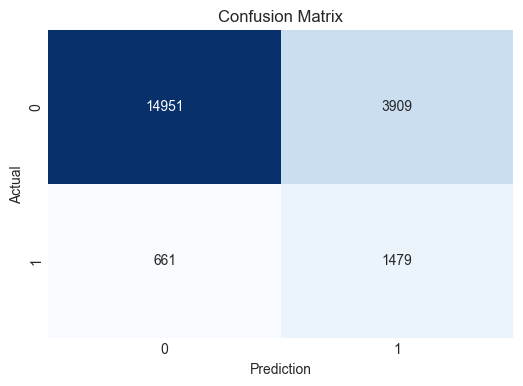

In [22]:
cm = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()

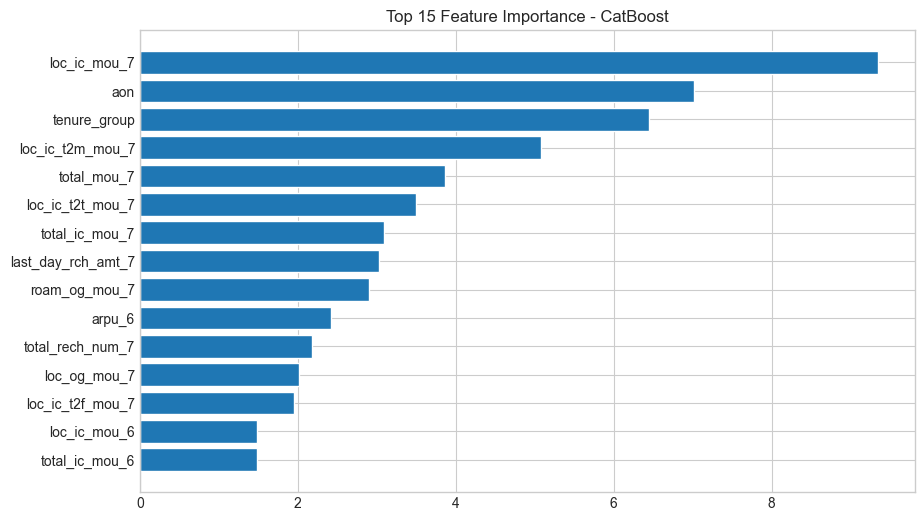

In [23]:
feature_importance = cb_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)[-15:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(X.columns)[sorted_idx])
plt.title('Top 15 Feature Importance - CatBoost')
plt.show()

--- Overfitting Check (Numeric) ---
Training ROC-AUC Score   : 0.8692
Validation ROC-AUC Score : 0.8294
Difference (Gap)         : 0.0398
-> GOOD FIT: The model is well-balanced and generalizes well!

--- Visualizing Learning Curve ---
Keys recorded by the model: ['learn', 'validation_0', 'validation_1']
Training Data Metrics (validation_0): ['Logloss', 'AUC']
Validation Data Metrics (validation_1): ['Logloss', 'AUC']


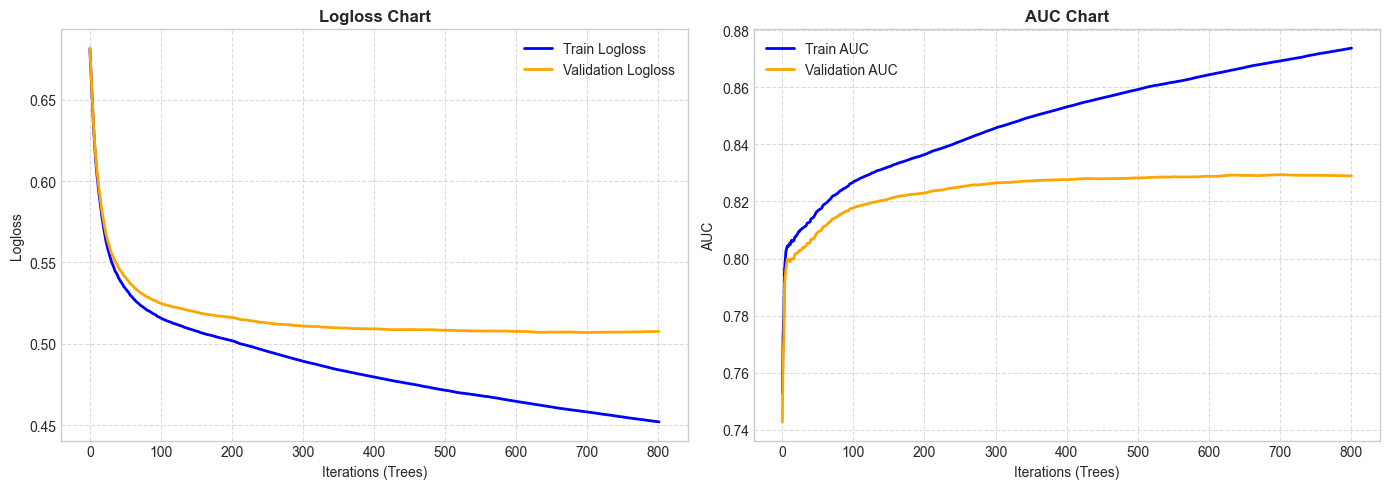

In [24]:
print("--- Overfitting Check (Numeric) ---")

# Predict probabilities on Training data
y_train_pred_proba = cb_model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, y_train_pred_proba)

# Predict probabilities on Validation data (done previously, calling it again)
y_val_pred_proba = cb_model.predict_proba(X_val)[:, 1]
val_auc = roc_auc_score(y_val, y_val_pred_proba)

print(f"Training ROC-AUC Score   : {train_auc:.4f}")
print(f"Validation ROC-AUC Score : {val_auc:.4f}")

# Calculate the difference (Gap)
gap = train_auc - val_auc
print(f"Difference (Gap)         : {gap:.4f}")

if gap > 0.05:
    print("-> OVERFITTING Indication: The model memorizes the training data too much!")
elif gap < 0:
    print("-> UNDERFITTING Indication: Something is wrong with the data splitting.")
else:
    print("-> GOOD FIT: The model is well-balanced and generalizes well!")

import matplotlib.pyplot as plt

print("\n--- Visualizing Learning Curve ---")

# Retrieve metric history from CatBoost
evals_result = cb_model.get_evals_result()

# Check which keys are actually recorded by CatBoost
available_keys = list(evals_result.keys())
print(f"Keys recorded by the model: {available_keys}")

# Automatically determine the correct keys
train_key = 'validation_0' if 'validation_0' in available_keys else 'learn'
val_key = 'validation_1' if 'validation_1' in available_keys else 'validation'

# Ensure data exists before plotting
if train_key in available_keys and val_key in available_keys:
    learn_metrics = list(evals_result[train_key].keys())
    val_metrics = list(evals_result[val_key].keys())

    print(f"Training Data Metrics ({train_key}): {learn_metrics}")
    print(f"Validation Data Metrics ({val_key}): {val_metrics}")

    num_metrics = len(learn_metrics)
    fig, axes = plt.subplots(1, num_metrics, figsize=(7 * num_metrics, 5))

    # If there is only 1 metric, ensure axes remains a list to avoid loop errors
    if num_metrics == 1:
        axes = [axes]

    for i, metric_name in enumerate(learn_metrics):
        # Plot line for Training Data
        axes[i].plot(evals_result[train_key][metric_name], label=f'Train {metric_name}', color='blue', linewidth=2)
        
        # Plot line for Validation Data (if the metric exists)
        if metric_name in val_metrics:
            axes[i].plot(evals_result[val_key][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
            
        axes[i].set_title(f'{metric_name} Chart', fontweight='bold')
        axes[i].set_xlabel('Iterations (Trees)')
        axes[i].set_ylabel(metric_name)
        axes[i].legend()
        axes[i].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

--- Loading ROC-AUC Learning Curve Data ---
Available data keys in your CatBoost model: ['learn', 'validation_0', 'validation_1']


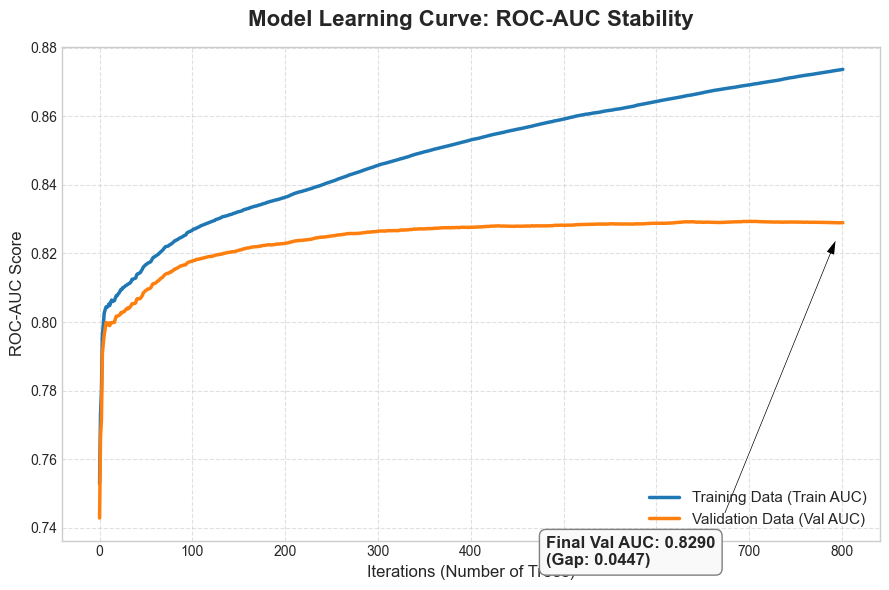

In [25]:
print("--- Loading ROC-AUC Learning Curve Data ---")

evals_result = cb_model.get_evals_result()
print(f"Available data keys in your CatBoost model: {list(evals_result.keys())}")

train_auc = None
if 'validation_0' in evals_result and 'AUC' in evals_result['validation_0']:
    train_auc = evals_result['validation_0']['AUC']
elif 'learn' in evals_result and 'AUC' in evals_result['learn']:
    train_auc = evals_result['learn']['AUC']

val_auc = None
if 'validation_1' in evals_result and 'AUC' in evals_result['validation_1']:
    val_auc = evals_result['validation_1']['AUC']
elif 'validation' in evals_result and 'AUC' in evals_result['validation']:
    val_auc = evals_result['validation']['AUC']

if train_auc and val_auc:
    plt.figure(figsize=(9, 6))

    plt.plot(train_auc, label='Training Data (Train AUC)', color='#1f77b4', linewidth=2.5)
    plt.plot(val_auc, label='Validation Data (Val AUC)', color='#ff7f0e', linewidth=2.5)

    plt.title('Model Learning Curve: ROC-AUC Stability', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Iterations (Number of Trees)', fontsize=12)
    plt.ylabel('ROC-AUC Score', fontsize=12)
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.6)

    final_train_auc = train_auc[-1]
    final_val_auc = val_auc[-1]
    gap_score = final_train_auc - final_val_auc

    plt.annotate(f'Final Val AUC: {final_val_auc:.4f}\n(Gap: {gap_score:.4f})', 
                 xy=(len(val_auc)-1, final_val_auc),
                 xytext=(len(val_auc)*0.6, final_val_auc-0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=7),
                 fontsize=12, fontweight='bold', bbox=dict(boxstyle="round,pad=0.4", fc="#f9f9f9", ec="gray"))

    plt.tight_layout()
    plt.show()

else:
    print("\n[WARNING] AUC data for Train or Validation was not found.")
    print("Make sure you have run the `cb_model.fit(...)` cell with the parameter `eval_set=[(X_train, y_train), (X_val, y_val)]` BEFORE running this plotting cell.")

--- Starting 5-Fold Cross Validation ---

Fold 1...
  Train AUC      : 0.8632
  Validation AUC : 0.8395

Fold 2...
  Train AUC      : 0.8683
  Validation AUC : 0.8358

Fold 3...
  Train AUC      : 0.8580
  Validation AUC : 0.8326

Fold 4...
  Train AUC      : 0.8540
  Validation AUC : 0.8322

Fold 5...
  Train AUC      : 0.8638
  Validation AUC : 0.8235

FINAL CROSS VALIDATION RESULTS (Average):
Average Train AUC      : 0.8615
Average Validation AUC : 0.8327
Difference (Gap)       : 0.0287

-> CONCLUSION: GOOD FIT! The model is very stable and generalizes well across all scenarios.


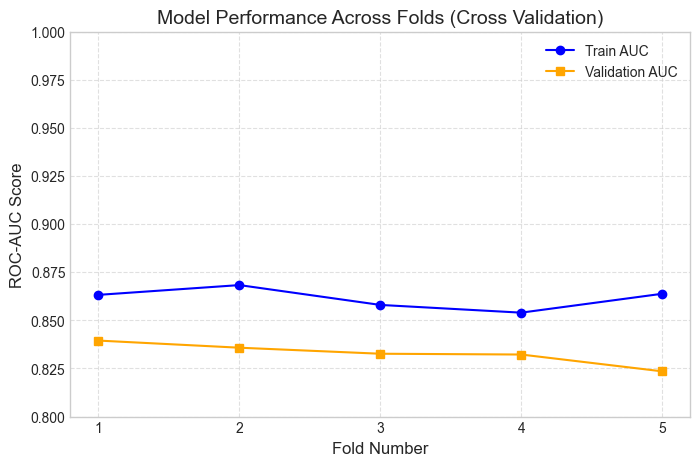

In [ ]:
n_splits = 5 
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

train_auc_scores = []
val_auc_scores = []
print(f"--- Starting {n_splits}-Fold Cross Validation ---")

# Loop for Training & Evaluation per Fold
fold = 1
for train_idx, val_idx in skf.split(X, y):
    print(f"\nFold {fold}...")

    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    model_cv = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.05,
        depth=3,
        eval_metric='AUC',
        auto_class_weights='Balanced',
        cat_features=cat_features,
        l2_leaf_reg=10,
        random_seed=42,
        early_stopping_rounds=50,
        verbose=False 
    )

    model_cv.fit(X_train_cv, y_train_cv, eval_set=(X_val_cv, y_val_cv), use_best_model=True)

    y_train_pred = model_cv.predict_proba(X_train_cv)[:, 1]
    y_val_pred = model_cv.predict_proba(X_val_cv)[:, 1]

    train_auc = roc_auc_score(y_train_cv, y_train_pred)
    val_auc = roc_auc_score(y_val_cv, y_val_pred)

    train_auc_scores.append(train_auc)
    val_auc_scores.append(val_auc)
    
    print(f"  Train AUC      : {train_auc:.4f}")
    print(f"  Validation AUC : {val_auc:.4f}")
    
    fold += 1

mean_train_auc = np.mean(train_auc_scores)
mean_val_auc = np.mean(val_auc_scores)
gap = mean_train_auc - mean_val_auc

print("\n==========================================")
print("FINAL CROSS VALIDATION RESULTS (Average):")
print("==========================================")
print(f"Average Train AUC      : {mean_train_auc:.4f}")
print(f"Average Validation AUC : {mean_val_auc:.4f}")
print(f"Difference (Gap)       : {gap:.4f}")

if gap > 0.05:
    print("\n-> CONCLUSION: Strong indication of OVERFITTING! The model memorized the training data.")
elif gap < 0:
    print("\n-> CONCLUSION: Indication of UNDERFITTING! (Validation score is higher, usually due to data leakage/error).")
else:
    print("\n-> CONCLUSION: GOOD FIT! The model is very stable and generalizes well across all scenarios.")

# Visualizing Model Stability
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_splits+1), train_auc_scores, label='Train AUC', marker='o', color='blue')
plt.plot(range(1, n_splits+1), val_auc_scores, label='Validation AUC', marker='s', color='orange')

plt.title('Model Performance Across Folds (Cross Validation)', fontsize=14)
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.xticks(range(1, n_splits+1))
plt.ylim(0.80, 1.0) 
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- Processing SHAP Values (Extracting AI Logic) ---


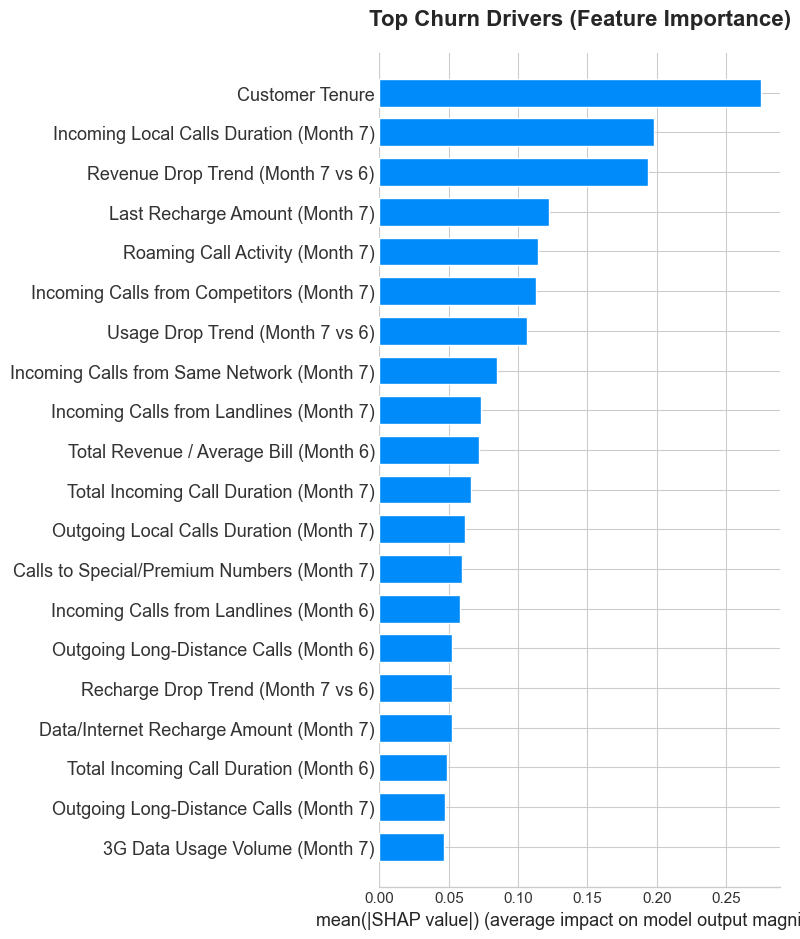

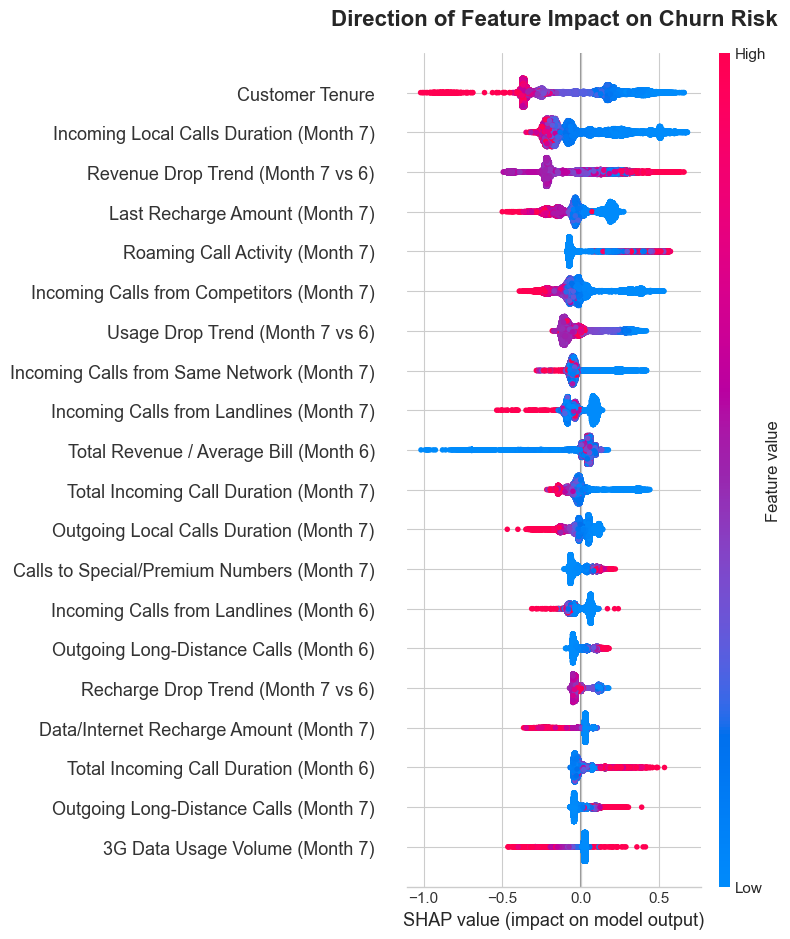

In [29]:
import shap
feature_mapping = {
    'aon': 'Customer Tenure',
    'loc_ic_mou_7': 'Incoming Local Calls Duration (Month 7)',
    'diff_arpu_7_vs_6': 'Revenue Drop Trend (Month 7 vs 6)',
    'last_day_rch_amt_7': 'Last Recharge Amount (Month 7)',
    'roam_og_mou_7': 'Roaming Call Activity (Month 7)',
    'loc_ic_t2m_mou_7': 'Incoming Calls from Competitors (Month 7)',
    'diff_mou_7_vs_6': 'Usage Drop Trend (Month 7 vs 6)',
    'loc_ic_t2t_mou_7': 'Incoming Calls from Same Network (Month 7)',
    'loc_ic_t2f_mou_7': 'Incoming Calls from Landlines (Month 7)',
    'arpu_6': 'Total Revenue / Average Bill (Month 6)',
    'total_ic_mou_7': 'Total Incoming Call Duration (Month 7)',
    'loc_og_mou_7': 'Outgoing Local Calls Duration (Month 7)',
    'spl_og_mou_7': 'Calls to Special/Premium Numbers (Month 7)',
    'loc_ic_t2f_mou_6': 'Incoming Calls from Landlines (Month 6)',
    'std_og_mou_6': 'Outgoing Long-Distance Calls (Month 6)',
    'diff_rech_amt_7_vs_6': 'Recharge Drop Trend (Month 7 vs 6)',
    'av_rech_amt_data_7': 'Data/Internet Recharge Amount (Month 7)',
    'total_ic_mou_6': 'Total Incoming Call Duration (Month 6)',
    'std_og_mou_7': 'Outgoing Long-Distance Calls (Month 7)',
    'vol_3g_mb_7': '3G Data Usage Volume (Month 7)'
}

X_val_renamed = X_val.rename(columns=feature_mapping)

print("--- Processing SHAP Values (Extracting AI Logic) ---")
explainer = shap.TreeExplainer(cb_model)

shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(10, 6))
plt.title("Top Churn Drivers (Feature Importance)", fontsize=16, fontweight='bold', pad=20)

shap.summary_plot(shap_values, X_val_renamed, plot_type="bar", show=False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.title("Direction of Feature Impact on Churn Risk", fontsize=16, fontweight='bold', pad=20)

shap.summary_plot(shap_values, X_val_renamed, show=False)

plt.tight_layout()
plt.show()

In [ ]:
y_pred = cb_model.predict(X_val)

y_pred_proba = cb_model.predict_proba(X_val)[:, 1]

accuracy  = accuracy_score(y_val, y_pred)
auc       = roc_auc_score(y_val, y_pred_proba)
recall    = recall_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
f1        = f1_score(y_val, y_pred)

print("\n=== Model Performance Summary ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"AUC       : {auc:.4f}")
print(f"Recall    : {recall:.4f}  <-- (Main focus for catching churners!)")
print(f"Precision : {precision:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("=================================\n")

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'AUC', 'Recall', 'Precision', 'F1-Score'],
    'Score': [accuracy, auc, recall, precision, f1]
}).round(4) 

display(metrics_df)


=== Model Performance Summary ===
Accuracy  : 0.7824
AUC       : 0.8294
Recall    : 0.6911  <-- (Main focus for catching churners!)
Precision : 0.2745
F1-Score  : 0.3929



,Metric,Score
0,Accuracy,0.7824
1,AUC,0.8294
2,Recall,0.6911
3,Precision,0.2745
4,F1-Score,0.3929
